In [1]:
!pip -q install "tensorflow-cpu==2.19.0" "tensorboard==2.19.0"
!pip -q install chess numpy pandas tqdm scikit-learn
!apt-get install -q -y stockfish

Reading package lists...
Building dependency tree...
Reading state information...
stockfish is already the newest version (14.1-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [2]:
import sys, os, math, csv, shutil, gdown, io
os.makedirs("final_model", exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

import chess, chess.engine, chess.svg

from tqdm import tqdm
from google.colab import files
from tensorflow.keras import layers, models, callbacks, Input
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from IPython.display import SVG, display

# Part 1: Load Data
Load ~20k Lichess games from a CSV stored on Google Drive.
We download the file, read it with pandas, and keep only the moves column since that’s all we need to generate board positions later.

In [3]:
def upload_chess_games(max_rows=None):
    print("Upload your games CSV file (must contain a 'moves' column)")
    uploaded = files.upload()

    if not uploaded:
        print("No file uploaded.")
        return None

    filename = next(iter(uploaded))
    try:
        games_df = pd.read_csv(io.BytesIO(uploaded[filename]), nrows=max_rows)

        if "moves" not in games_df.columns:
            raise ValueError("Missing required column: 'moves'")

        games_df = games_df[["moves"]].copy()

        print(f"CSV loaded successfully with {len(games_df)} rows.")
        return games_df

    except Exception as err:
        print(f"Error loading CSV: {err}")
        return None


games_df = upload_chess_games()

if games_df is not None:
    print(games_df.head())

Upload your games CSV file (must contain a 'moves' column)


Saving games.csv to games.csv
CSV loaded successfully with 20058 rows.
                                               moves
0  d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...
1  d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...
2  e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...
3  d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...
4  e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...


# Part 2: Building Game States and Stockfish Labelling
Convert each game into board positions and label them with Stockfish evaluations.
We step through every game, save the board state (FEN) every ply_skip moves to reduce redundancy, and build a dataset of positions.
Then we run Stockfish on each FEN to get an evaluation:

- Mate scores → mapped directly to 0 or 1

- Centipawn scores → clipped and converted to a win probability

The final output is a CSV where each position has:

- fen (board state)

- y_gt (Stockfish win probability target)

This becomes the supervised training data for the CNN.
Convert each game into board positions and label them with Stockfish evaluations.
We step through every game, save the board state (FEN) every ply_skip moves to reduce redundancy, and build a dataset of positions.


## Important

We currently have ~1.2 million positions.

If we allocate 0.1 seconds per position for Stockfish evaluation:

 - 1,200,000 × 0.1 seconds = 120,000 seconds | 33.3 hours

If you do not want to wait for labelling:
You can upload the already processed & labelled dataset of ~100k positions available on GitHub.
This allows you to skip the Stockfish step entirely and move directly to model training.

In [4]:
def build_position_dataset(df) -> pd.DataFrame:
    records = []

    for moves in tqdm(df["moves"], total=len(df), desc="Processing games"):
        if not isinstance(moves, str) or not moves.strip():
            continue

        board = chess.Board()
        for san in moves.split():
            records.append({"fen": board.fen()})
            try:
                board.push(board.parse_san(san))
            except Exception:
                break

    return pd.DataFrame(records)

if games_df is not None:
    game_states = build_position_dataset(games_df)

    print("Total positions to label with Stockfish:", len(game_states))
    game_states.to_csv("processed_game_states.csv", index=False)
    print(game_states.head())

Processing games: 100%|██████████| 20058/20058 [01:44<00:00, 192.69it/s]


Total positions to label with Stockfish: 1212827
                                                 fen
0  rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...
1  rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR ...
2  rnbqkbnr/ppp1pppp/8/3p4/3P4/8/PPP1PPPP/RNBQKBN...
3  rnbqkbnr/ppp1pppp/8/3p4/2PP4/8/PP2PPPP/RNBQKBN...
4  rnbqkbnr/pp2pppp/2p5/3p4/2PP4/8/PP2PPPP/RNBQKB...


In [ ]:
stockfish_path = "/usr/games/stockfish"

def cp_to_prob(cp, k=0.004):
    return 1 / (1 + math.exp(-k * float(cp)))

in_path = "processed_game_states.csv"
out_path = in_path + ".tmp"

with chess.engine.SimpleEngine.popen_uci(stockfish_path) as engine, \
     open(in_path, newline="") as fin, open(out_path, "w", newline="") as fout:

    reader = csv.DictReader(fin)
    if not reader.fieldnames or "fen" not in reader.fieldnames:
        raise ValueError("CSV must contain a 'fen' column")

    fieldnames = list(reader.fieldnames)
    if "y_gt" not in fieldnames:
        fieldnames.append("y_gt")

    writer = csv.DictWriter(fout, fieldnames=fieldnames)
    writer.writeheader()

    for idx, row in enumerate(reader, 1):
        if row.get("y_gt") not in (None, "", "nan", "NaN"):
            writer.writerow(row)
            continue

        try:
            board = chess.Board(row["fen"])
            info = engine.analyse(board, chess.engine.Limit(time=0.1))
            score = info["score"].white()

            if score.is_mate():
                row["y_gt"] = 1.0 if (score.mate() or 0) > 0 else 0.0
            else:
                cp = score.score()
                row["y_gt"] = "" if cp is None else cp_to_prob(max(min(cp, 2000), -2000))

        except Exception:
            row["y_gt"] = ""

        writer.writerow(row)

files.download("processed_game_states.csv")
os.replace(out_path, in_path)

# Part 3: Train the model
Turn each FEN into an 8×8×28 tensor: 12 planes for piece locations, plus extra planes for side to move, castling rights, en-passant file, move counters, and check.

Load the labeled positions (y_gt), drop any bad rows, then build X and y and split into train/val.

The model is a small CNN that predicts a single value in [0,1] (sigmoid), trained with MSE against the Stockfish win-prob targets. We save the best checkpoint, log losses to CSV, periodically dump models, and drop LR when validation loss stalls.

In [5]:
print("Upload your processed_game_states.csv file")
uploaded = files.upload()

filename = next(iter(uploaded))
game_df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("Loaded file:", filename)
print("Total rows before cleaning:", len(game_df))

def fen_to_tensor(fen: str) -> np.ndarray:
    piece_to_channel = {
        "P": 0, "N": 1, "B": 2, "R": 3, "Q": 4, "K": 5,
        "p": 6, "n": 7, "b": 8, "r": 9, "q": 10, "k": 11,
    }

    board = chess.Board(fen)
    tensor = np.zeros((8, 8, 28), dtype=np.float32)

    for square in chess.SQUARES:
        piece = board.piece_at(square)
        if piece:
            r = 7 - (square // 8)
            f = square % 8
            tensor[r, f, piece_to_channel[piece.symbol()]] = 1.0

    if board.turn == chess.WHITE:
        tensor[:, :, 12] = 1.0

    if board.has_kingside_castling_rights(chess.WHITE):
        tensor[:, :, 13] = 1.0
    if board.has_queenside_castling_rights(chess.WHITE):
        tensor[:, :, 14] = 1.0
    if board.has_kingside_castling_rights(chess.BLACK):
        tensor[:, :, 15] = 1.0
    if board.has_queenside_castling_rights(chess.BLACK):
        tensor[:, :, 16] = 1.0

    if board.ep_square is not None:
        ep_file = chess.square_file(board.ep_square)
        tensor[:, :, 17 + ep_file] = 1.0

    tensor[:, :, 25] = min(board.halfmove_clock, 100) / 100.0

    tensor[:, :, 26] = min(board.fullmove_number, 100) / 100.0

    tensor[:, :, 27] = 1.0 if board.is_check() else 0.0

    return tensor


game_df["y_gt"] = pd.to_numeric(game_df["y_gt"], errors="coerce")
game_df = game_df.dropna(subset=["fen", "y_gt"])

print("Rows after cleaning:", len(game_df))

print("Converting FENs to tensors...")
X = np.stack([fen_to_tensor(fen) for fen in game_df["fen"]], axis=0).astype(np.float32)
y = game_df[["y_gt"]].values.astype(np.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])


Upload your processed_game_states.csv file


Saving processed_game_states.csv to processed_game_states.csv
Loaded file: processed_game_states.csv
Total rows before cleaning: 100000
Rows after cleaning: 100000
Converting FENs to tensors...
X shape: (100000, 8, 8, 28)
y shape: (100000, 1)
Training samples: 90000
Validation samples: 10000


In [6]:
def build_model() -> tf.keras.Model:
    board_in = Input(shape=(8, 8, 28), name="board_tensor_in")

    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(board_in)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    pred = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs=board_in, outputs=pred)
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

model = build_model()
model.summary()

class TrainingCSVLogger(callbacks.Callback):
    def __init__(self, log_path: str):
        super().__init__()
        self.log_file = open(log_path, "w", newline="")
        self.csv_writer = csv.writer(self.log_file)
        self.csv_writer.writerow(["epoch", "train_loss", "val_loss"])

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.csv_writer.writerow([epoch + 1, logs.get("loss"), logs.get("val_loss")])
        self.log_file.flush()

    def on_train_end(self, logs=None):
        self.log_file.close()

class PeriodicModelSaver(callbacks.Callback):
    def __init__(self, directory_prefix: str = "final_model"):
        super().__init__()
        self.directory_prefix = directory_prefix
        os.makedirs(self.directory_prefix, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            self.model.save(os.path.join(self.directory_prefix, f"epoch_{epoch+1}.keras"))

os.makedirs("final_model", exist_ok=True)

best_model_path = "final_model/best_model.keras"
best_checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=best_model_path,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

csv_log_cb = TrainingCSVLogger("final_model/training_log.csv")
periodic_save_cb = PeriodicModelSaver("final_model")

lr_scheduler_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

training_history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[csv_log_cb, periodic_save_cb, best_checkpoint_cb, lr_scheduler_cb]
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ board_tensor_in (InputLayer)    │ (None, 8, 8, 28)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 8, 8, 64)       │        16,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 310,401 (1.18 MB)

 Trainable params: 309,121 (1.18 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/30
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0830 - mae: 0.2175
Epoch 1: val_loss improved from inf to 0.03109, saving model to final_model/best_model.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 152s 105ms/step - loss: 0.0830 - mae: 0.2175 - val_loss: 0.0311 - val_mae: 0.1244 - learning_rate: 0.0010
Epoch 2/30
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0337 - mae: 0.1300
Epoch 2: val_loss did not improve from 0.03109
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 140s 100ms/step - loss: 0.0337 - mae: 0.1300 - val_loss: 0.0340 - val_mae: 0.1354 - learning_rate: 0.0010
Epoch 3/30
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0257 - mae: 0.1117
Epoch 3: val_loss improved from 0.03109 to 0.02275, saving model to final_model/best_model.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 140s 99ms/step - loss: 0.0257 - mae: 0.1117 - val_loss: 0.0228 - val_mae: 0.0998 - learning_rate: 0.0010
Epoch 4/30
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0215 - mae: 0.1011
Epoch 4: val_los

# Part 4: Analysis
Read the training log CSV and plot train vs validation loss over epochs (log scale). Saves the figure to final_model/training_progress.png so you can track overfitting and whether LR drops helped.

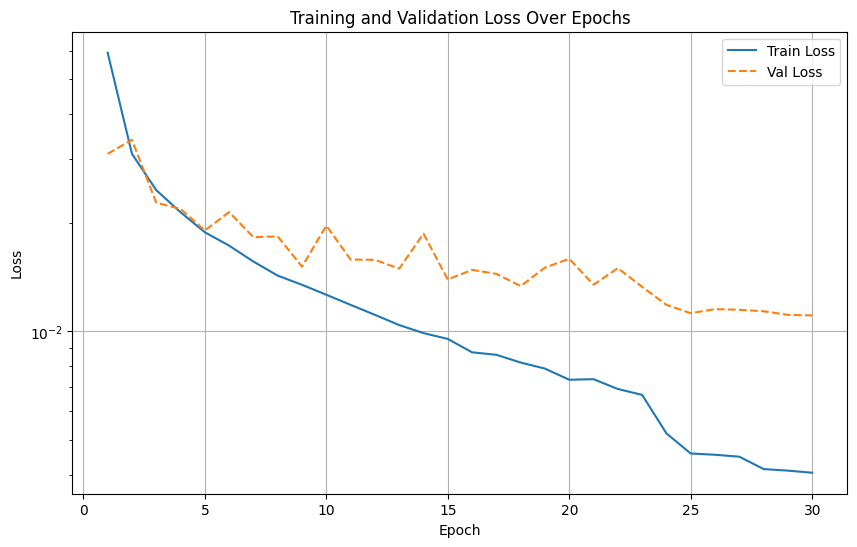

In [7]:
def plot_training_progress(csv_file: str):
    df = pd.read_csv(csv_file)

    plt.figure(figsize=(10, 6))
    plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
    plt.plot(df["epoch"], df["val_loss"], label="Val Loss", linestyle="--")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.yscale("log")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.savefig("final_model/training_progress.png")
    plt.show()

plot_training_progress("final_model/training_log.csv")

# Part 5: Model Usage
Load the best saved model and run a forward pass on a single FEN. The FEN is converted to the same 8×8×28 input format, then the model outputs a win-prob for White. Finally, render the position to visually check the input.

Input state: r1bq1rk1/pp1n1ppp/2pbpn2/3p4/2PP4/2N1PN2/PP3PPP/R1BQ1RK1 w - - 4 10
Predicted probability: 0.5131387710571289


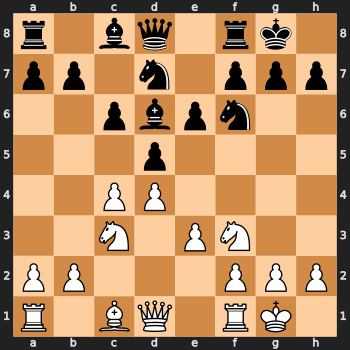

In [9]:
tf.get_logger().setLevel("ERROR")

def predict_from_fen(fen: str, model_path: str = "final_model/best_model.keras") -> float:
    model = load_model(model_path, compile=False)
    board_tensor = fen_to_tensor(fen)
    board_input = np.expand_dims(board_tensor, axis=0)
    pred = model.predict(board_input, verbose=0)
    return float(pred[0, 0])

model_path = "final_model/best_model.keras"
fen = "r1bq1rk1/pp1n1ppp/2pbpn2/3p4/2PP4/2N1PN2/PP3PPP/R1BQ1RK1 w - - 4 10"

print(f"Input state: {fen}")
pred = predict_from_fen(fen, model_path=model_path)
print("Predicted probability:", pred)

board = chess.Board(fen)
display(SVG(chess.svg.board(board, size=350)))